# Exploratory Data Analysis — Used Car Price Prediction

This notebook is exploration only. It inspects structure, quality, and relationships,
and documents the cleaning/feature decisions that follow — but does not execute or
persist them. Those live in `02_data_cleaning.ipynb` (as functions in `src/data_prep.py`)
and `03_feature_engineering.ipynb` (as functions in `src/features.py`), so the pipeline
logic is reusable and testable rather than trapped in EDA cells.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [20]:
df = pd.read_csv("../data/raw/train-data.csv")
df.shape

(6019, 14)

In [21]:
df.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         6019 non-null   int64  
 1   Name               6019 non-null   str    
 2   Location           6019 non-null   str    
 3   Year               6019 non-null   int64  
 4   Kilometers_Driven  6019 non-null   int64  
 5   Fuel_Type          6019 non-null   str    
 6   Transmission       6019 non-null   str    
 7   Owner_Type         6019 non-null   str    
 8   Mileage            6017 non-null   str    
 9   Engine             5983 non-null   str    
 10  Power              5983 non-null   str    
 11  Seats              5977 non-null   float64
 12  New_Price          824 non-null    str    
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), str(9)
memory usage: 658.5 KB


In [23]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,6019.0,NaN,NaN,NaN,3009.0,1737.679967,0.0,1504.5,3009.0,4513.5,6018.0
Name,6019,1876,Mahindra XUV500 W8 2WD,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,6019,11,Mumbai,790,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,6019.0,NaN,NaN,NaN,2013.358199,3.269742,1998.0,2011.0,2014.0,2016.0,2019.0
Kilometers_Driven,6019.0,NaN,NaN,NaN,58738.380296,91268.843206,171.0,34000.0,53000.0,73000.0,6500000.0
Fuel_Type,6019,5,Diesel,3205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,6019,2,Manual,4299,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner_Type,6019,4,First,4929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mileage,6017,442,18.9 kmpl,172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine,5983,146,1197 CC,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
df[['Unnamed: 0', 'Price']].corr()

,Unnamed: 0,Price
Unnamed: 0,1.000000,-0.020275
Price,-0.020275,1.000000


Correlation is ~0 — this is a leftover row index with no relationship to Price.
**Decision (executed in 02_data_cleaning):** drop this column.

In [25]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0')

,missing_count,missing_pct
New_Price,5195,86.31
Seats,42,0.70
Engine,36,0.60
Power,36,0.60
Mileage,2,0.03


`Engine`, `Power`, `Seats`, `Mileage` — under 1% missing each, reasonable to impute later.
`New_Price` — missing for the large majority of rows; too sparse to impute credibly.
**Decision (executed in 02_data_cleaning):** replace `New_Price` with a binary
`Had_New_Price` flag, drop the raw column. Leave the small-missingness columns as
NaN here — actual imputation belongs inside the preprocessing `Pipeline`, fit on
the training split only.

In [26]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.sort_values('Kilometers_Driven', ascending=False).head(10)[['Name', 'Year', 'Kilometers_Driven', 'Price']]

,Name,Year,Kilometers_Driven,Price
2328,BMW X5 xDrive 30d M Sport,2017,6500000,65.00
340,Skoda Octavia Ambition Plus 2.0 TDI AT,2013,775000,7.50
1860,Volkswagen Vento Diesel Highline,2013,720000,5.90
358,Hyundai i10 Magna 1.2,2009,620000,2.70
3092,Honda City i VTEC SV,2015,480000,5.00
2823,Volkswagen Jetta 2013-2015 2.0L TDI Highline AT,2015,480000,13.00
4491,Hyundai i20 Magna Optional 1.2,2013,445000,4.45
3649,Tata Indigo LS,2008,300000,1.00
1528,Toyota Innova 2.5 G (Diesel) 8 Seater BS IV,2005,299322,4.00
1975,Skoda Superb 1.8 TSI MT,2012,282000,3.30


Top row: 6,500,000 km — physically implausible (~2,300+ km/day sustained). Almost
certainly a data-entry error. The next-highest values (700K–775K km) are high but
plausible for fleet/commercial use, so this is a single corrupted row, not a
systemic issue.

**Decision (executed in 02_data_cleaning):** drop rows with `Kilometers_Driven >= 1,000,000`
— a threshold chosen well above the highest legitimate value and nowhere near the
corrupted one, so it removes only the bad row.

In [30]:
_temp = df[df['Kilometers_Driven'] < 1_000_000]
_temp['Kilometers_Driven'].describe()

count      6018.000000
mean      57668.047690
std       37878.783175
min         171.000000
25%       34000.000000
50%       53000.000000
75%       73000.000000
max      775000.000000
Name: Kilometers_Driven, dtype: float64

`Engine`, `Power`, `Mileage` are numeric data stored as strings because of embedded
units (`"1582 CC"`, `"126.2 bhp"`, mixed `kmpl`/`km per kg`). We parse temporary
copies here purely to plot/correlate them — the real parsing logic (including
handling the literal string `"null bhp"` via `pd.to_numeric(errors='coerce')`, and
keeping Mileage's value and unit as separate columns since kmpl and km/kg aren't
directly comparable) is implemented as functions in `src/data_prep.py` and executed
in `02_data_cleaning`.

In [31]:
_engine_numeric = pd.to_numeric(df['Engine'].str.replace(' CC', '', regex=False), errors='coerce')
_power_numeric = pd.to_numeric(df['Power'].str.replace(' bhp', '', regex=False), errors='coerce')
_mileage_split = df['Mileage'].str.split(' ', expand=True)
_mileage_numeric = pd.to_numeric(_mileage_split[0], errors='coerce')

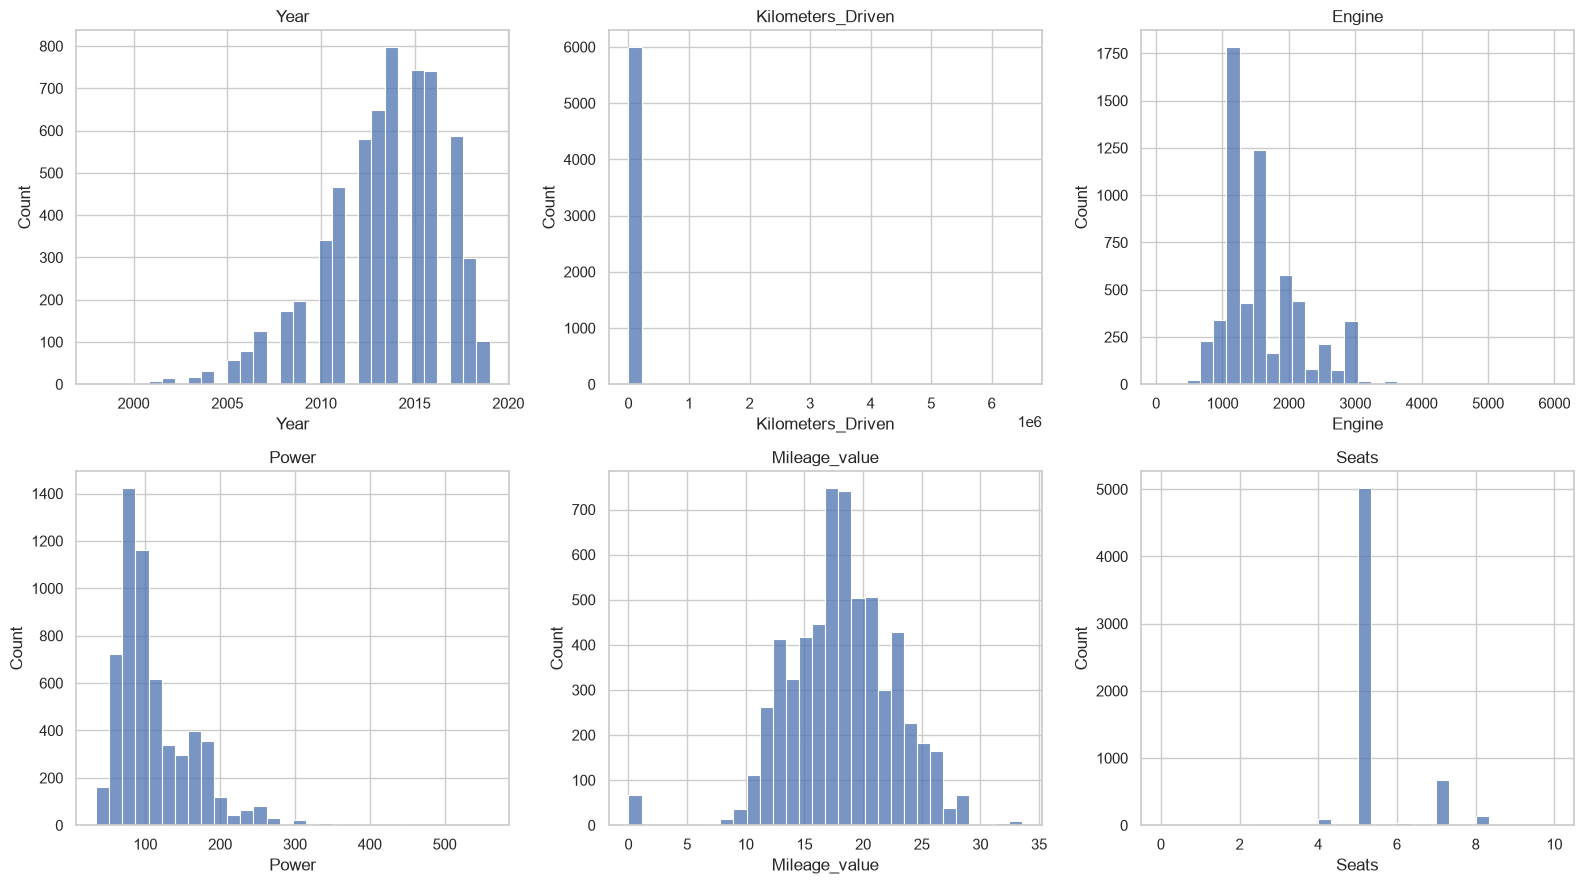

In [32]:
_plot_df = pd.DataFrame({
    'Year': df['Year'],
    'Kilometers_Driven': df['Kilometers_Driven'],
    'Engine': _engine_numeric,
    'Power': _power_numeric,
    'Mileage_value': _mileage_numeric,
    'Seats': df['Seats'],
})

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), _plot_df.columns):
    sns.histplot(_plot_df[col].dropna(), bins=30, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

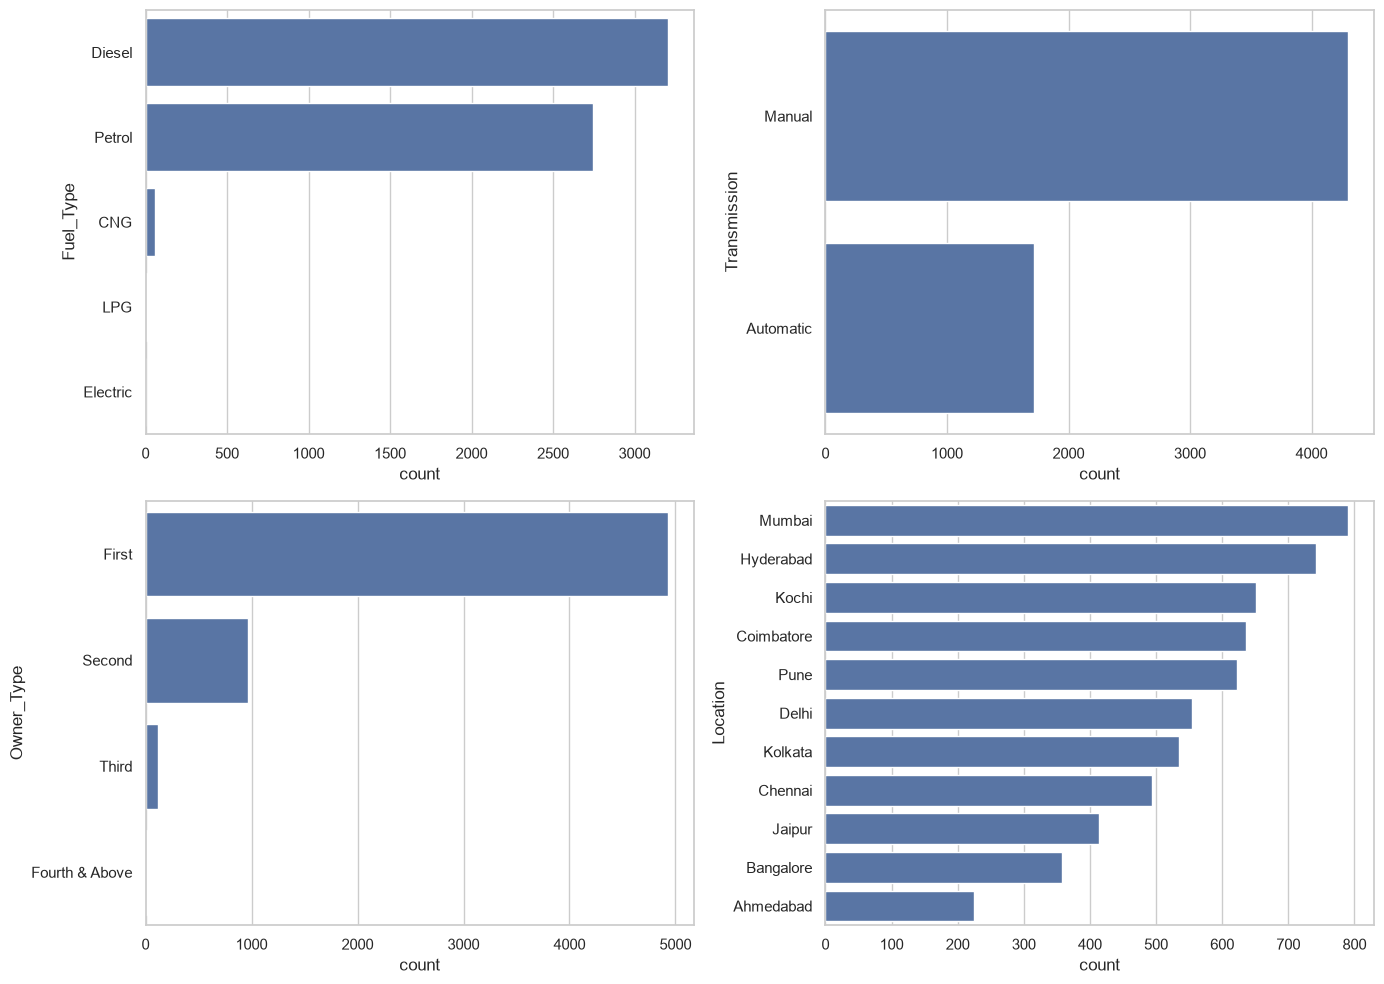

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(data=df, y='Fuel_Type', order=df['Fuel_Type'].value_counts().index, ax=axes[0,0])
sns.countplot(data=df, y='Transmission', order=df['Transmission'].value_counts().index, ax=axes[0,1])
sns.countplot(data=df, y='Owner_Type', order=df['Owner_Type'].value_counts().index, ax=axes[1,0])
sns.countplot(data=df, y='Location', order=df['Location'].value_counts().index, ax=axes[1,1])
plt.tight_layout()
plt.show()

In [34]:
df['Price'].describe()

count    6019.000000
mean        9.479468
std        11.187917
min         0.440000
25%         3.500000
50%         5.640000
75%         9.950000
max       160.000000
Name: Price, dtype: float64

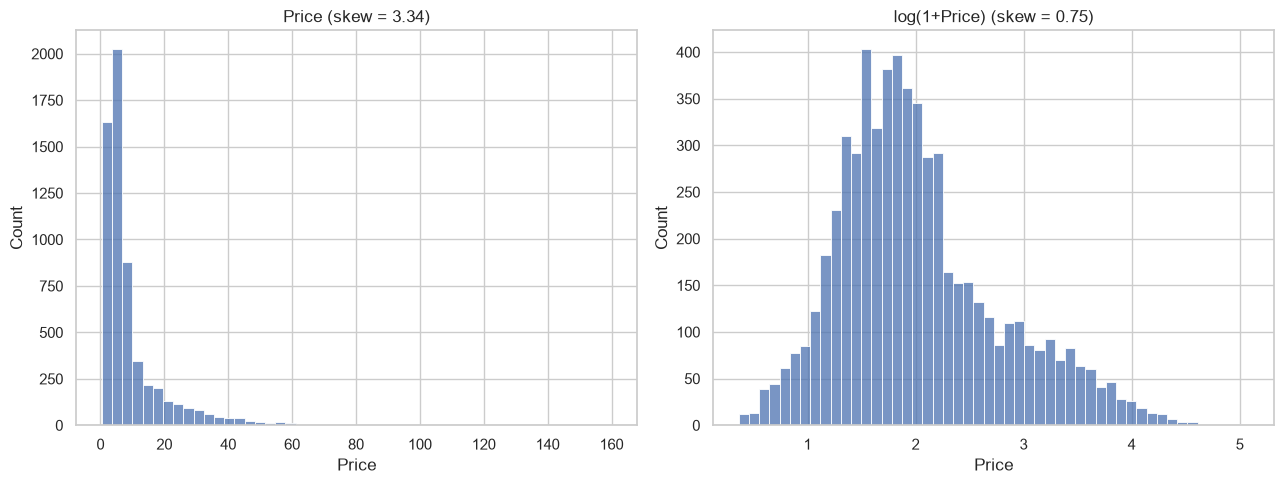

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df['Price'], bins=50, ax=axes[0])
axes[0].set_title(f"Price (skew = {df['Price'].skew():.2f})")
sns.histplot(np.log1p(df['Price']), bins=50, ax=axes[1])
axes[1].set_title(f"log(1+Price) (skew = {np.log1p(df['Price']).skew():.2f})")
plt.tight_layout()
plt.show()

Price is heavily right-skewed; log(Price) is close to symmetric. Candidate for
modeling the log-transformed target — final call made in the modeling notebook.

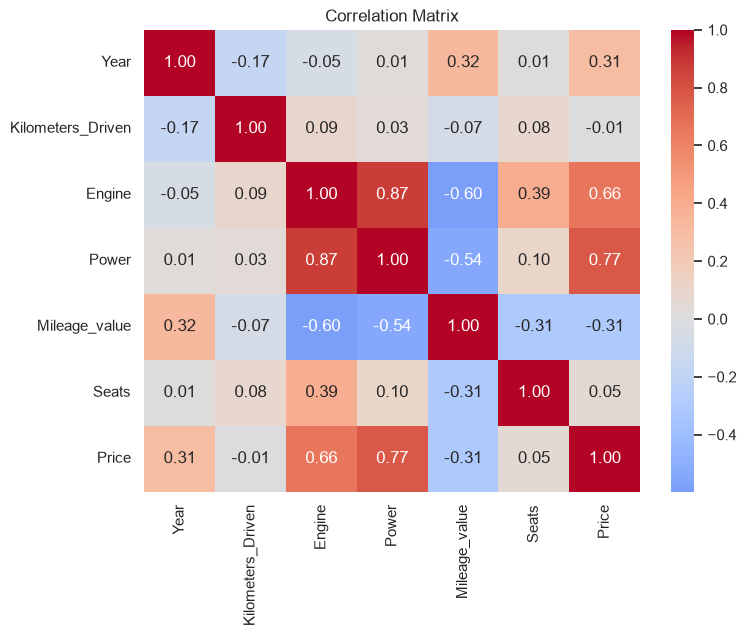

In [36]:
_corr_df = _plot_df.copy()
_corr_df['Price'] = df['Price']
corr_matrix = _corr_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

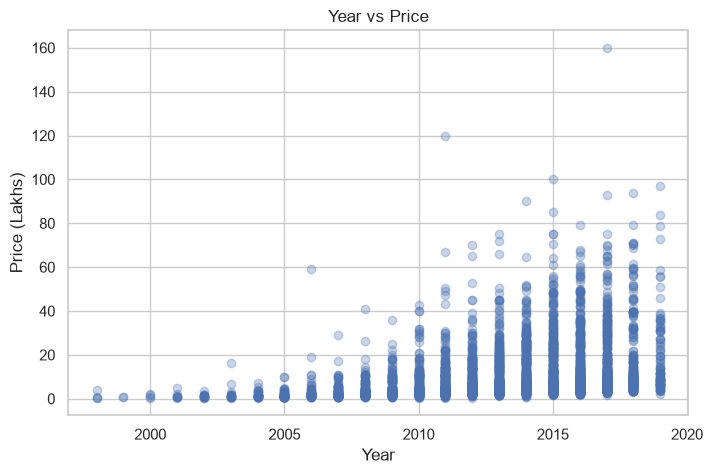

In [37]:
plt.scatter(df['Year'], df['Price'], alpha=0.3)
plt.xlabel('Year'); plt.ylabel('Price (Lakhs)'); plt.title('Year vs Price')
plt.show()

Correlation reads weak-to-moderate, but the scatter is visibly curved (depreciation
shape), not linear. Pearson only detects straight-line relationships, so it
understates this. First evidence a plain linear model will underfit.    

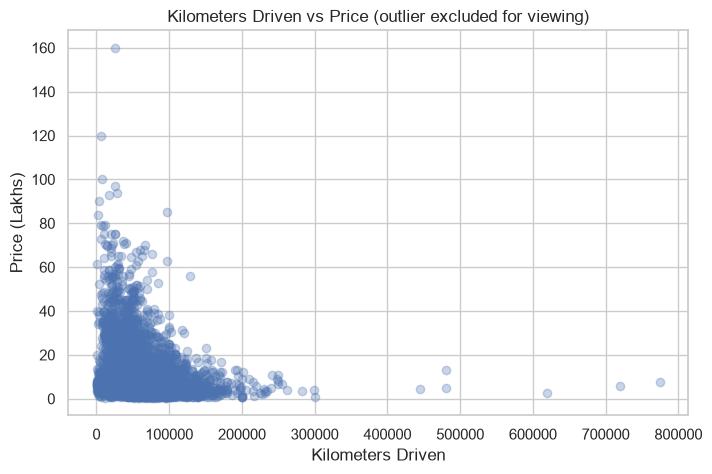

In [38]:
_km_plot = df[df['Kilometers_Driven'] < 1_000_000]

plt.scatter(_km_plot['Kilometers_Driven'], _km_plot['Price'], alpha=0.3)
plt.xlabel('Kilometers Driven'); plt.ylabel('Price (Lakhs)')
plt.title('Kilometers Driven vs Price (outlier excluded for viewing)')
plt.show()

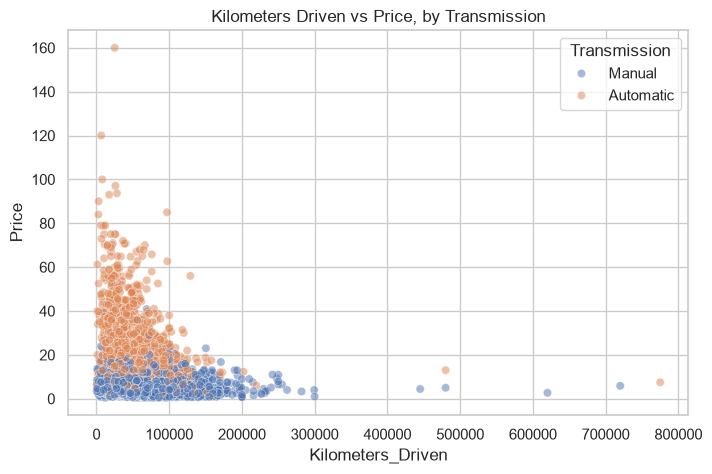

In [39]:
sns.scatterplot(data=_km_plot, x='Kilometers_Driven', y='Price', hue='Transmission', alpha=0.5)
plt.title('Kilometers Driven vs Price, by Transmission')
plt.show()

Raw correlation ~0, and the unfiltered scatter looks shapeless — not because mileage
doesn't matter, but because Price depends jointly on segment/brand/engine at once.
Splitting by Transmission (a rough segment proxy) reveals it: automatics occupy
almost the entire high-price band regardless of mileage; manuals dominate both the
low-price and high-mileage regions. The mileage effect is real but conditional —
second piece of evidence for non-linear/interaction effects.

(Splitting the same plot by `Fuel_Type` instead was tried and showed no separation —
included as a negative result, not because it worked.)

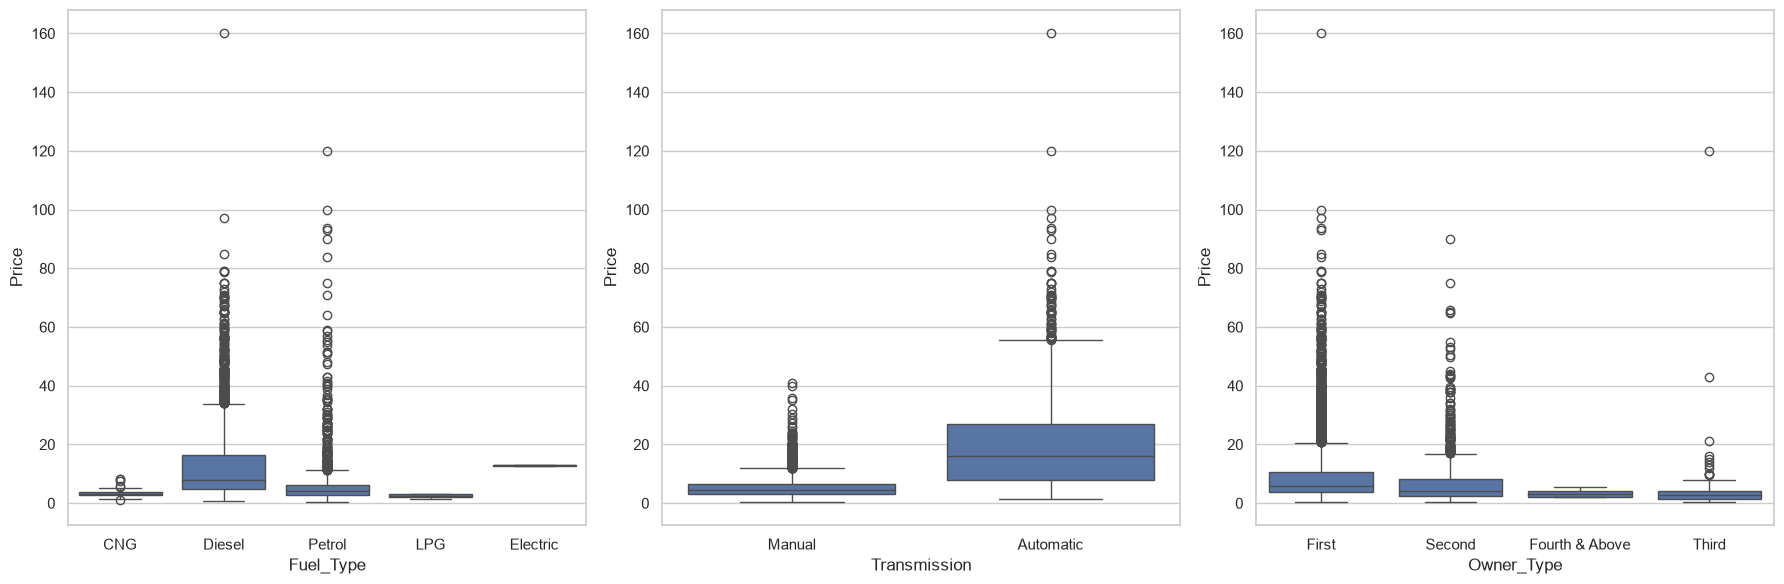

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.boxplot(data=df, x='Fuel_Type', y='Price', ax=axes[0])
sns.boxplot(data=df, x='Transmission', y='Price', ax=axes[1])
sns.boxplot(data=df, x='Owner_Type', y='Price', ax=axes[2])
plt.tight_layout()
plt.show()

In [41]:
_transmission_encoded = df['Transmission'].map({'Manual': 0, 'Automatic': 1})
pd.DataFrame({'Transmission_encoded': _transmission_encoded, 'Price': df['Price']}).corr()

,Transmission_encoded,Price
Transmission_encoded,1.000000,0.586025
Price,0.586025,1.000000


Transmission is a genuine binary, so encoding it 0/1 and correlating is valid
(point-biserial correlation). This does **not** generalize to nominal columns like
Fuel_Type or Brand — label-encoding those and correlating would produce a number
that changes with the arbitrary label order, i.e. not a real measurement. Group
means (boxplots above, or `groupby`) are the correct tool for those instead.

In [42]:
_brand_temp = df['Name'].str.split(' ').str[0]
df.assign(Brand=_brand_temp).groupby('Brand')['Price'].mean().sort_values(ascending=False).head(15)

Brand
Lamborghini      120.000000
Bentley           59.000000
Porsche           48.348333
Land              39.259500
Jaguar            37.632250
Mini              26.896923
Mercedes-Benz     26.809874
Audi              25.537712
BMW               25.243146
Isuzu             20.000000
Volvo             18.802857
Jeep              18.718667
ISUZU             12.045000
Toyota            11.580024
Mitsubishi        11.058889
Name: Price, dtype: float64

Brand extraction shown here for exploration only — the real, persisted
`Brand`/`Model` split happens in `03_feature_engineering`, as a function in
`src/features.py`.

## Key EDA Findings

**Feeds into `02_data_cleaning` (src/data_prep.py):**
- Drop `Unnamed: 0` (checked, ~0 correlation with Price — not just assumed useless).
- Drop rows with `Kilometers_Driven >= 1,000,000` (single corrupted row, not a systemic issue).
- Parse `Engine`/`Power` to numeric (strip units; `Power` needs `errors='coerce'` for `"null bhp"`).
- Split `Mileage` into `Mileage_value` + `Mileage_unit` (kmpl vs km/kg are not directly comparable).
- Replace `New_Price` with `Had_New_Price` binary flag; drop raw column (86%+ missing, not credibly imputable).

**Feeds into `03_feature_engineering` (src/features.py):**
- Extract `Brand` and `Model` from `Name`. `Model` has high cardinality — plain
  one-hot encoding is the wrong tool; needs grouping of rare categories or
  target/frequency encoding.

**Feeds into modeling notebooks:**
- `Price` is right-skewed; consider modeling `log(Price)`.
- `Year` vs `Price` and `Kilometers_Driven` vs `Price` are both non-linear/conditional
  relationships that a plain linear model will underfit — supports including
  regularized linear models and tree-based models in the comparison, not linear
  regression alone.

**Explicitly not done in this notebook:** no missing-value imputation, no
categorical encoding — both depend on training-set-only statistics and belong in
the `Pipeline`/`ColumnTransformer` built after the train/test split.